<a href="https://colab.research.google.com/github/Zinc-zn/MachineLearning2026/blob/main/JS05_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# JS05 - Klasifikasi 1: Lab 2 (Klasifikasi Naive Bayes dengan Data Dummy)

Pada percobaan ini kita akan menggunakan data dummy (sintetis) untuk membuat sebuah model Naive Bayes. Untuk membuat data dummy, kita dapat menggunakan fungsi `make_classification` dari library scikit-learn. Selanjutnya, kita akan membuat model **Multinomial Naive Bayes** menggunakan `MultinomialNB` dan model **Gaussian Naive Bayes** menggunakan `GaussianNB`.


## Langkah 1 - Buat Dataset Dummy

In [1]:
import numpy as np
from sklearn.datasets import make_classification

# Membuat data dummy
# Hasil dari make_classification berupa data fitur X dan label y
# Label y akan berupa data yang sudah di encode (angka)
X, y = make_classification(n_samples=30, n_features=2, n_classes=2,
                           n_informative=2, n_redundant=0, n_repeated=0, shuffle=False,
                           random_state=1)  # random_state ditambahkan agar hasil dapat direproduksi (sesuai contoh pada modul)

# Secara default, make_classification menghasilkan nilai float
# Kita perlu merubah dalam bentuk diskrit

# Absolutekan nilai
X = np.absolute(X)

# Bulatkan nilai ke 2 angka dibelakang koma
# Kalikan dengan 100 supaya tidak ada lagi koma
X = np.round(X, 2) * 100

# Ubah ke dalam bentuk integer
X = X.astype(int)

# Cek Hasil
print(X)
print(y)

[[ 10 198]
 [ 77 169]
 [ 49 308]
 [ 23 213]
 [ 73 129]
 [ 68 307]
 [ 99 121]
 [  8 221]
 [126  63]
 [ 82 118]
 [ 47  26]
 [ 97 196]
 [135 167]
 [129  66]
 [ 79  88]
 [103  26]
 [161 175]
 [152 161]
 [184 197]
 [ 35  61]
 [124 131]
 [141 141]
 [102 105]
 [266 121]
 [148 103]
 [ 66  79]
 [ 93 155]
 [151 120]
 [160  70]
 [166  98]]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1]


**Keterangan parameter** `make_classification`:

* `n_samples`: jumlah sampel yang diinginkan
* `n_features`: jumlah fitur yang digunakan
* `n_classes`: jumlah kelas
* `n_informative`: jumlah fitur yang memiliki korelasi dengan kelas
* `n_redundant`: jumlah fitur yang tidak memiliki korelasi dengan kelas
* `n_repeated`: jumlah fitur yang diulang

## Langkah 2 (Opsional) - Membuat Data Frame

Agar data lebih mudah untuk dibaca, maka kita akan membuat DataFrame dengan menggunakan library Pandas berdasarkan data dummy yang telah dibuat sebelumnya.

In [2]:
import pandas as pd

# Reshape label y menjadi 2D
# Hal ini dilakukan karena kita akan menggabungkannya dengan data fitur X
y_new = y.reshape(len(y), 1)

# Gabungkan fitur X dan label y dalam data array
data = np.concatenate((X, y_new), axis=1)

# Definisikan nama kolom
nama_kolom = ['Fitur 1', 'Fitur 2', 'Label']

# Buat Data Frame
df = pd.DataFrame(data, columns=nama_kolom)

# Cek Data Frame
df.head()

,Fitur 1,Fitur 2,Label
0,10,198,0
1,77,169,0
2,49,308,0
3,23,213,0
4,73,129,0


## Langkah 3 (Opsional) - Labeling

Dikarenakan label masih berbentuk encoding angka, untuk mempermudah pembacaan data, kita dapat mengubah bentuknya dalam bentuk kategorial.

In [3]:
# Definisikan nama label
labels = {
    1: 'Kelas A',
    0: 'Kelas B'
}

# Copy Data Frame untuk menyimpan Data Frame baru
# dengan label yang mudah untuk dibaca
df_label = df.copy()

# Ubah label dengan fungsi mapping dari Pandas
# pada Data Frame df_label
df_label['Label'] = df_label['Label'].map(labels)

# Cek Data Frame df_label
df_label.head()

,Fitur 1,Fitur 2,Label
0,10,198,Kelas B
1,77,169,Kelas B
2,49,308,Kelas B
3,23,213,Kelas B
4,73,129,Kelas B


## Langkah 4 - Visualisasi Data

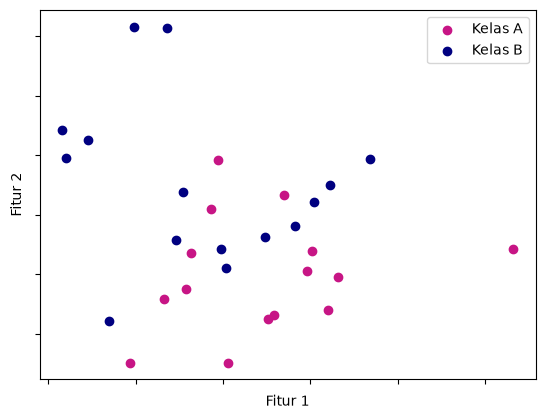

In [4]:
import matplotlib.pyplot as plt

# Definisikan warna untuk setiap kelas
colors = {
    'class_a': 'MediumVioletRed',
    'class_b': 'Navy'
}

# Kelompokkan label berdasarkan nama kelas
# (Catatan: pada pandas >= 3.0, groupby dengan list ['Label'] membuat get_group skalar
#  gagal, sehingga digunakan bentuk groupby('Label') yang kompatibel di semua versi)
gb = df_label.groupby('Label')
class_a = gb.get_group('Kelas A')
class_b = gb.get_group('Kelas B')

# Plot
plt.scatter(x=class_a['Fitur 1'], y=class_a['Fitur 2'], c=colors['class_a'])
plt.scatter(x=class_b['Fitur 1'], y=class_b['Fitur 2'], c=colors['class_b'])
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.legend(['Kelas A', 'Kelas B'])
plt.gca().axes.xaxis.set_ticklabels([])
plt.gca().axes.yaxis.set_ticklabels([])
plt.show()

## Langkah 5 - Model Multinomial Naive Bayes

Selanjutnya buat model Naive Bayes dengan jenis multinomial. Sejatinya, ***model multinomial digunakan untuk fitur yang bersifat diskrit*** (e.g. jumlah kata untuk klasifikasi teks). Akan tetapi kita akan mencoba menggunakan model ini untuk konteks data kontinu ***hanya sebagai pembelajaran***.

In [5]:
from sklearn.naive_bayes import MultinomialNB  # class untuk model MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score  # evaluasi model berdasarkan akurasi

# Inisiasi obyek MultinomialNB
mnb = MultinomialNB()

# Kita dapat langsung menggunakan fitur X dan label y
# hasil dari proses pembuatan data dummy

# Split data training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=30)

# Fit model
# Label y harus dalam bentuk 1D atau (n_samples,)
mnb.fit(X_train, y_train)

# Prediksi dengan data training
y_train_pred = mnb.predict(X_train)

# Evaluasi akurasi training
acc_train = accuracy_score(y_train, y_train_pred)

# Prediksi test data
y_test_pred = mnb.predict(X_test)

# Evaluasi model dengan metric akurasi
acc_test = accuracy_score(y_test, y_test_pred)

# Print hasil evaluasi
print(f'Hasil akurasi data train: {acc_train}')
print(f'Hasil akurasi data test: {acc_test}')

Hasil akurasi data train: 0.6190476190476191
Hasil akurasi data test: 0.7777777777777778


## Langkah 6 - Model Gaussian Naive Bayes

Model Gaussian lebih cocok digunakan untuk data kontinu yang kita miliki, hal ini dikarenakan model ini menggunakan distribusi gaussian (normal) yang secara alami memiliki rentang dengan nilai kontinu.

In [6]:
from sklearn.naive_bayes import GaussianNB  # class untuk model GaussianNB

# Inisiasi obyek Gaussian
gnb = GaussianNB()

# Kita menggunakan split data training dan testing
# yang sama dengan model multinomial

# Fit model
# Label y harus dalam bentu 1D atau (n_samples,)
gnb.fit(X_train, y_train)

# Prediksi dengan data training
y_train_pred_gnb = gnb.predict(X_train)

# Evaluasi akurasi training
acc_train_gnb = accuracy_score(y_train, y_train_pred_gnb)

# Prediksi test data
y_test_pred_gnb = gnb.predict(X_test)

# Evaluasi model dengan metric akurasi
acc_test_gnb = accuracy_score(y_test, y_test_pred_gnb)

# Print hasil evaluasi
print(f'Hasil akurasi data train (Gaussian): {acc_train_gnb}')
print(f'Hasil akurasi data test (Gaussian): {acc_test_gnb}')

Hasil akurasi data train (Gaussian): 0.6666666666666666
Hasil akurasi data test (Gaussian): 0.4444444444444444


Meskipun hasilnya tidak jauh berbeda dengan model multinomial, secara teoritis kita telah menerapkan langkah yang benar dalam membuat sebuah model klasifikasi dengan menggunakan Naive Bayes.

> **Catatan:** Parameter `random_state=1` pada `make_classification` ditambahkan agar data dummy (beserta angka akurasinya) tetap sama setiap kali notebook dijalankan ulang.